In [1]:
# %% [0] 라이브러리 준비
# 이 실습은 numpy/pandas/matplotlib만으로 "관계 탐색"을 충분히 연습합니다.
# (seaborn 없이도 히트맵을 그릴 수 있게 구성했습니다.)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 재현 가능성을 위해 난수 시드 고정 (같은 결과가 나오게 해줌)
np.random.seed(42)


In [2]:


# %% [1] 예제 데이터 만들기: 관계가 "있는/없는/비선형" 3종 세트
# 왜 가상 데이터를 쓰나요?
# - 처음 배우는 단계에서는 "상관이 왜 이렇게 나오지?"를 체감해야 합니다.
# - 실데이터는 노이즈/결측/복잡성이 섞여 있어 개념이 흐려질 수 있어요.
# - 가상 데이터는 특정 상황(선형/비선형/무관)을 의도적으로 만들어 학습할 수 있습니다.

n = 200

# 1) x: 기준이 되는 독립 변수(설명 변수) 역할
x = np.random.normal(loc=0, scale=1, size=n)

# 2) y_linear: x와 "선형" 관계(대체로 x가 커지면 y도 커지게 만듦)
#    y = 0.8*x + 노이즈
y_linear = 0.8 * x + np.random.normal(loc=0, scale=0.7, size=n)

# 3) y_nonlinear: x와 "비선형" 관계(U자 형태 등)
#    y = x^2 + 노이즈
#    이 경우 Pearson 상관계수는 약하게 나올 수도 있습니다.
y_nonlinear = x**2 + np.random.normal(loc=0, scale=0.5, size=n)

# 4) z: x와 거의 관계가 없는 변수(무관하게 생성)
z = np.random.normal(loc=0, scale=1, size=n)

# 데이터프레임으로 묶어서 분석 편하게 만들기
df = pd.DataFrame({
    "x": x,
    "y_linear": y_linear,
    "y_nonlinear": y_nonlinear,
    "z": z
})

df.head()


,x,y_linear,y_nonlinear,z
0,0.496714,0.647822,-0.550489,0.756989
1,-0.138264,0.281938,-0.280570,-0.922165
2,0.647689,1.276287,0.422122,0.869606
3,1.523030,1.956085,2.343110,1.355638
4,-0.234153,-1.151691,-0.170205,0.413435


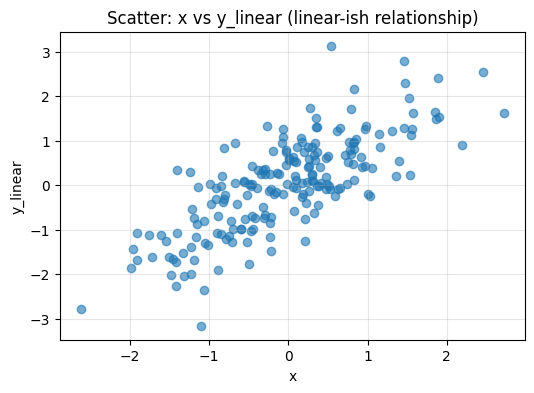

In [3]:


# %% [2] 산점도: 숫자(상관계수)보다 먼저 "그림"을 봐야 하는 이유
# 산점도를 보면 다음을 바로 확인할 수 있습니다.
# 1) 방향: x가 증가할 때 y가 대체로 증가? 감소?
# 2) 강도: 점들이 "한 줄"에 가깝게 모이나? 넓게 퍼지나?
# 3) 형태: 직선형? 곡선형? 특정 구간만 패턴?
# 4) 이상치: 튀는 점 몇 개가 전체를 왜곡하나?

plt.figure(figsize=(6, 4))
plt.scatter(df["x"], df["y_linear"], alpha=0.6)
plt.title("Scatter: x vs y_linear (linear-ish relationship)")
plt.xlabel("x")
plt.ylabel("y_linear")
plt.grid(True, alpha=0.3)
plt.show()


In [4]:


# %% [3] 상관계수: 관계를 "숫자로 요약"하는 도구
# pandas의 corr()은 기본적으로 Pearson 상관계수를 계산합니다.
# Pearson은 "선형(직선) 관계"에 특히 민감합니다.

r_xy = df["x"].corr(df["y_linear"])   # 기본은 Pearson
print("Pearson corr(x, y_linear) =", r_xy)

# 여러 변수 간 상관행렬(상관계수 표)
# - (행, 열)의 교차 값이 해당 두 변수의 상관계수입니다.
corr_mat = df.corr(numeric_only=True)
print("\nCorrelation matrix (Pearson):")
print(corr_mat)



Pearson corr(x, y_linear) = 0.7624919070355759

Correlation matrix (Pearson):
                    x  y_linear  y_nonlinear         z
x            1.000000  0.762492    -0.021235  0.065398
y_linear     0.762492  1.000000    -0.093351 -0.020081
y_nonlinear -0.021235 -0.093351     1.000000  0.034229
z            0.065398 -0.020081     0.034229  1.000000


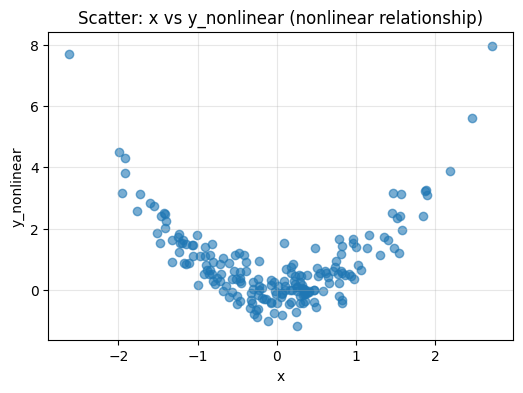

Pearson corr(x, y_nonlinear) = -0.021235402518313937


In [5]:

# %% [4] "r≈0인데도 관계가 있을 수 있다"를 직접 체감: 비선형 사례
# y_nonlinear는 x^2 형태로 만들어져서 U자 패턴이 나타납니다.
# Pearson은 "직선" 관계를 잘 잡으므로, 이런 경우 상관이 약하게 나올 수 있습니다.

plt.figure(figsize=(6, 4))
plt.scatter(df["x"], df["y_nonlinear"], alpha=0.6)
plt.title("Scatter: x vs y_nonlinear (nonlinear relationship)")
plt.xlabel("x")
plt.ylabel("y_nonlinear")
plt.grid(True, alpha=0.3)
plt.show()

r_xn = df["x"].corr(df["y_nonlinear"])
print("Pearson corr(x, y_nonlinear) =", r_xn)

# 핵심 메시지:
# - r이 0에 가깝다고 "관계가 없다"라고 단정하면 위험합니다.
# - 더 정확히는 "선형 관계가 약하다"라고 해석하는 편이 안전합니다.


In [6]:


# %% [5] Spearman 상관계수(선택): "순위 기반" 관계를 보는 방법
# Spearman은 값의 크기 자체보다 "순서(랭킹)"를 이용해서 관계를 봅니다.
# - 비선형이어도 '단조(monotonic)' 관계면 더 잘 잡는 경우가 있습니다.
# - 이상치에도 Pearson보다 덜 흔들리는 경향이 있습니다.

spearman_mat = df[["x", "y_linear", "y_nonlinear", "z"]].corr(method="spearman")
print("Correlation matrix (Spearman):")
print(spearman_mat)

# 지금 단계에서 Spearman을 깊게 다루기보다,
# "Pearson은 직선, Spearman은 순위 기반" 정도의 감각만 가져도 충분합니다.



Correlation matrix (Spearman):
                    x  y_linear  y_nonlinear         z
x            1.000000  0.740398    -0.106444  0.058119
y_linear     0.740398  1.000000    -0.158795 -0.036487
y_nonlinear -0.106444 -0.158795     1.000000  0.025262
z            0.058119 -0.036487     0.025262  1.000000


원본 Pearson corr(x, y_linear): 0.7624919070355759
이상치 포함 Pearson corr(x, y_linear): 0.5278793483442386


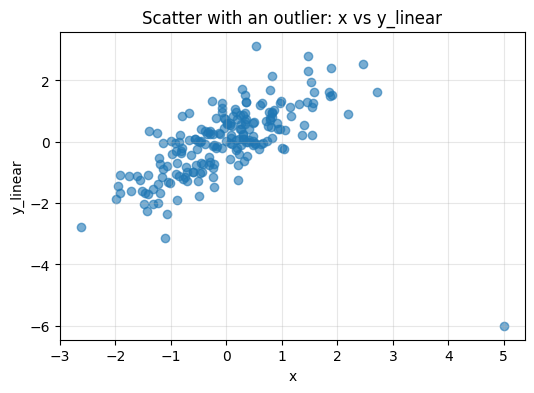

In [7]:

# %% [6] 이상치(outlier)가 상관계수를 어떻게 흔드는지 체감
# 상관계수는 전체 데이터를 "한 숫자"로 요약합니다.
# 그러다 보니, 튀는 점 1~2개가 요약값을 크게 바꿀 수 있습니다.

print("원본 Pearson corr(x, y_linear):", df["x"].corr(df["y_linear"]))

df_out = df.copy()

# 일부러 "이상치" 한 점 추가:
# - x는 매우 큰데 y는 매우 작은 값으로 설정하면
#   선형 관계를 강하게 왜곡할 수 있습니다.
df_out.loc[len(df_out)] = [5, -6, 25, 0]

print("이상치 포함 Pearson corr(x, y_linear):", df_out["x"].corr(df_out["y_linear"]))

plt.figure(figsize=(6, 4))
plt.scatter(df_out["x"], df_out["y_linear"], alpha=0.6)
plt.title("Scatter with an outlier: x vs y_linear")
plt.xlabel("x")
plt.ylabel("y_linear")
plt.grid(True, alpha=0.3)
plt.show()

# 결론:
# - 상관계수만 보고 결론 내리지 말고, 항상 산점도로 이상치 여부를 확인합니다.


In [8]:


# %% [7] 결측치(missing)가 상관계수에 미치는 영향
# 결측치가 많아지면 계산은 되더라도 "신뢰도"가 떨어질 수 있습니다.
# pandas corr()는 기본적으로 결측이 있는 쌍을 제외하고 계산하는(쌍별 제거) 경향이 있습니다.

df_na = df.copy()

# y_linear에 결측치 10개 만들기
na_idx = np.random.choice(df_na.index, 10, replace=False)
df_na.loc[na_idx, "y_linear"] = np.nan

print("결측치 개수:", df_na["y_linear"].isna().sum())

# 결측치가 있는 상태에서 corr 계산
print("결측 포함 Pearson corr(x, y_linear):", df_na["x"].corr(df_na["y_linear"]))

# 결측이 얼마나 있는지(비율)도 함께 확인하는 습관이 중요합니다.
missing_rate = df_na["y_linear"].isna().mean()
print("결측 비율:", missing_rate)


결측치 개수: 10
결측 포함 Pearson corr(x, y_linear): 0.7619143822322257
결측 비율: 0.05


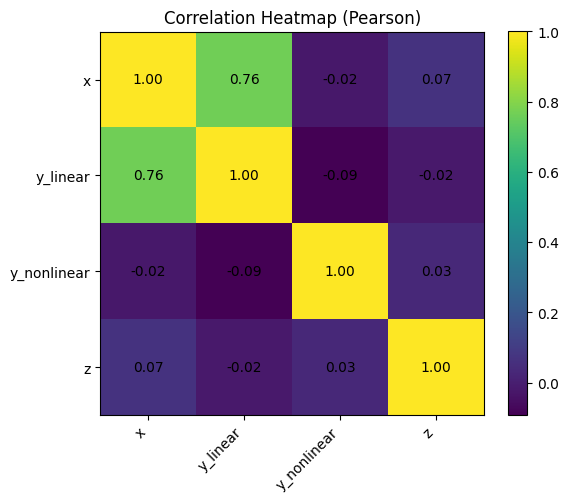

In [9]:


# %% [8] 히트맵(Heatmap): 상관행렬을 "색으로" 한눈에 보기
# 변수가 2개면 산점도로 충분합니다.
# 하지만 변수가 많아지면 모든 조합을 산점도로 보기 어렵습니다.
# 히트맵은 "상관이 강한 쌍"을 빠르게 스캔하는 도구입니다.

corr_mat = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_mat.values)  # 숫자 행렬을 이미지(색)로 표현

ax.set_title("Correlation Heatmap (Pearson)")
ax.set_xticks(range(len(corr_mat.columns)))
ax.set_yticks(range(len(corr_mat.index)))
ax.set_xticklabels(corr_mat.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_mat.index)

# 셀 안에 숫자를 써 넣어(annot 효과) 해석을 돕습니다.
for i in range(corr_mat.shape[0]):
    for j in range(corr_mat.shape[1]):
        ax.text(j, i, f"{corr_mat.values[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax)  # 색상 범례
plt.tight_layout()
plt.show()


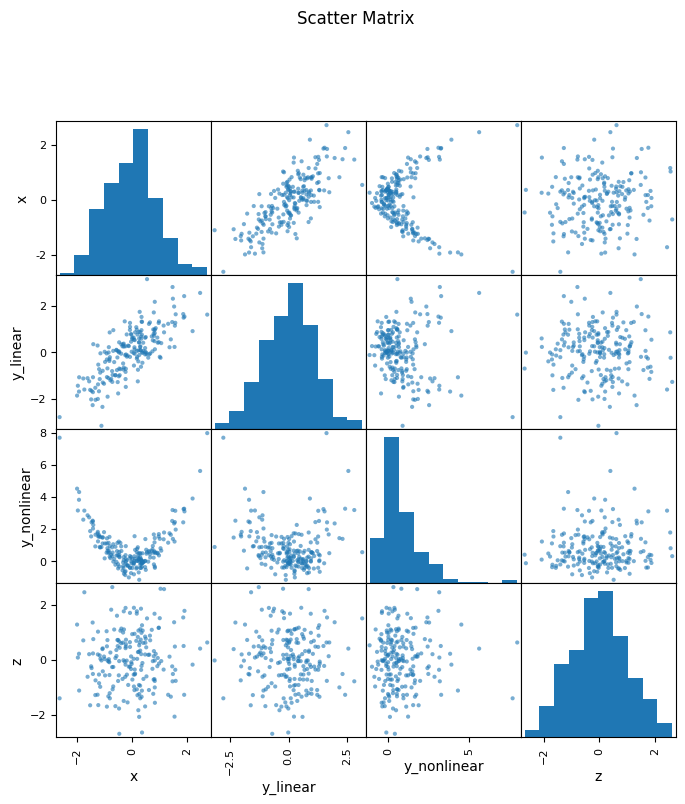

In [10]:

# 팁:
# - 히트맵만 보고도 "뭘 더 볼지" 후보를 뽑을 수 있습니다.
# - 그 다음 단계에서, "후보 쌍"을 산점도로 자세히 확인하면 좋습니다.


# %% [9] 산점도 행렬(Scatter Matrix): 다변수 관계를 "그림으로" 한 번에 보기
# 히트맵이 요약 숫자 기반이라면, 산점도 행렬은 "원본 모양" 기반입니다.
# 모양(비선형/군집/이상치)을 함께 보고 싶다면 산점도 행렬이 강력합니다.

from pandas.plotting import scatter_matrix

axes = scatter_matrix(
    df[["x", "y_linear", "y_nonlinear", "z"]],
    figsize=(8, 8),
    alpha=0.6
)

plt.suptitle("Scatter Matrix", y=1.02)
plt.show()



In [11]:

# %% [10] (미션) 스스로 확인해보는 연습 과제 3개
# 미션 1: 비선형 데이터를 더 강하게 만들면 Pearson/Spearman이 어떻게 바뀌나?
# 미션 2: 이상치 위치를 바꿔가며 corr 값이 얼마나 요동치는지 기록해보기
# 미션 3: 변수 6개를 만들고, 의도적으로 상관이 높은 변수 쌍을 섞은 뒤
#         히트맵에서 "정답 찾기" 게임 해보기

# ---- 미션 1 예시 코드 ----
np.random.seed(7)
x2 = np.random.normal(0, 1, 300)
y2 = x2**2 + np.random.normal(0, 0.3, 300)

pearson_1 = pd.Series(x2).corr(pd.Series(y2))
spearman_1 = pd.Series(x2).corr(pd.Series(y2), method="spearman")

print("[Mission 1] Pearson:", pearson_1)
print("[Mission 1] Spearman:", spearman_1)

plt.figure(figsize=(6, 4))
plt.scatter(x2, y2, alpha=0.6)
plt.title("Mission 1: Nonlinear relationship (x^2)")
plt.xlabel("x2")
plt.ylabel("y2")
plt.grid(True, alpha=0.3)
plt.show()


ModuleNotFoundError: No module named 'scipy'